In [ ]:
import requests 
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns 
import re

In [2]:
response=requests.get("https://books.toscrape.com/index.html")
response

<Response [200]>

In [3]:
response.content

b'<!DOCTYPE html>\n<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->\n<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->\n<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->\n<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->\n    <head>\n        <title>\n    All products | Books to Scrape - Sandbox\n</title>\n\n        <meta http-equiv="content-type" content="text/html; charset=UTF-8" />\n        <meta name="created" content="24th Jun 2016 09:29" />\n        <meta name="description" content="" />\n        <meta name="viewport" content="width=device-width" />\n        <meta name="robots" content="NOARCHIVE,NOCACHE" />\n\n        <!-- Le HTML5 shim, for IE6-8 support of HTML elements -->\n        <!--[if lt IE 9]>\n        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>\n        <![endif]-->\n\n        \n            <link rel="shortcut icon" hre

In [4]:
soup=BeautifulSoup(response.content,'html.parser')

In [5]:
soup

<!DOCTYPE html>

<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html class="no-js" lang="en-us"> <!--<![endif]-->
<head>
<title>
    All products | Books to Scrape - Sandbox
</title>
<meta content="text/html; charset=utf-8" http-equiv="content-type"/>
<meta content="24th Jun 2016 09:29" name="created"/>
<meta content="" name="description"/>
<meta content="width=device-width" name="viewport"/>
<meta content="NOARCHIVE,NOCACHE" name="robots"/>
<!-- Le HTML5 shim, for IE6-8 support of HTML elements -->
<!--[if lt IE 9]>
        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>
        <![endif]-->
<link href="static/oscar/favicon.ico" rel="shortcut icon"/>
<link href="static/oscar/css/styles.css" rel="stylesheet" type="text/css"/>
<link href="s

In [6]:
book_store=soup.find_all('div',{'class' :'row'})
book_store

[<div class="row">
 <div class="col-sm-8 h1"><a href="index.html">Books to Scrape</a><small> We love being scraped!</small>
 </div>
 </div>,
 <div class="row">
 <aside class="sidebar col-sm-4 col-md-3">
 <div id="promotions_left">
 </div>
 <div class="side_categories">
 <ul class="nav nav-list">
 <li>
 <a href="catalogue/category/books_1/index.html">
                             
                                 Books
                             
                         </a>
 <ul>
 <li>
 <a href="catalogue/category/books/travel_2/index.html">
                             
                                 Travel
                             
                         </a>
 </li>
 <li>
 <a href="catalogue/category/books/mystery_3/index.html">
                             
                                 Mystery
                             
                         </a>
 </li>
 <li>
 <a href="catalogue/category/books/historical-fiction_4/index.html">
                             
     

In [7]:
book_store=soup.find_all('article',{'class' :'product_pod'})
book_store

[<article class="product_pod">
 <div class="image_container">
 <a href="catalogue/a-light-in-the-attic_1000/index.html"><img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/></a>
 </div>
 <p class="star-rating Three">
 <i class="icon-star"></i>
 <i class="icon-star"></i>
 <i class="icon-star"></i>
 <i class="icon-star"></i>
 <i class="icon-star"></i>
 </p>
 <h3><a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">A Light in the ...</a></h3>
 <div class="product_price">
 <p class="price_color">£51.77</p>
 <p class="instock availability">
 <i class="icon-ok"></i>
     
         In stock
     
 </p>
 <form>
 <button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">Add to basket</button>
 </form>
 </div>
 </article>,
 <article class="product_pod">
 <div class="image_container">
 <a href="catalogue/tipping-the-velvet_999/index.html"><img alt="Tipping the Velvet" class="thu

In [8]:
book_store[0].select_one("h3 a")["title"]

'A Light in the Attic'

In [9]:
book_store[0].select_one("p.price_color").text

'£51.77'

In [10]:
book_store[0].select_one("p.star-rating")["class"][1]

'Three'

In [11]:
for i in range(len(book_store)):
    print(book_store[i].select_one("h3 a")["title"]," - ",(book_store[i]).select_one("p.price_color").text,book_store[i].select_one("p.star-rating")["class"][1])

A Light in the Attic  -  £51.77 Three
Tipping the Velvet  -  £53.74 One
Soumission  -  £50.10 One
Sharp Objects  -  £47.82 Four
Sapiens: A Brief History of Humankind  -  £54.23 Five
The Requiem Red  -  £22.65 One
The Dirty Little Secrets of Getting Your Dream Job  -  £33.34 Four
The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull  -  £17.93 Three
The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics  -  £22.60 Four
The Black Maria  -  £52.15 One
Starving Hearts (Triangular Trade Trilogy, #1)  -  £13.99 Two
Shakespeare's Sonnets  -  £20.66 Four
Set Me Free  -  £17.46 Five
Scott Pilgrim's Precious Little Life (Scott Pilgrim #1)  -  £52.29 Five
Rip it Up and Start Again  -  £35.02 Five
Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991  -  £57.25 Three
Olio  -  £23.88 One
Mesaerion: The Best Science Fiction Stories 1800-1849  -  £37.59 One
Libertarianism for Beginners  -  £51.33 Tw

In [12]:
for book in book_store:
    title = book.select_one("h3 a")["title"]
    price = book.select_one("p.price_color").text
    rating=book.select_one("p.star-rating")["class"][1]
    print(f"\"{title} - {price}-{rating}\"")


"A Light in the Attic - £51.77-Three"
"Tipping the Velvet - £53.74-One"
"Soumission - £50.10-One"
"Sharp Objects - £47.82-Four"
"Sapiens: A Brief History of Humankind - £54.23-Five"
"The Requiem Red - £22.65-One"
"The Dirty Little Secrets of Getting Your Dream Job - £33.34-Four"
"The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull - £17.93-Three"
"The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics - £22.60-Four"
"The Black Maria - £52.15-One"
"Starving Hearts (Triangular Trade Trilogy, #1) - £13.99-Two"
"Shakespeare's Sonnets - £20.66-Four"
"Set Me Free - £17.46-Five"
"Scott Pilgrim's Precious Little Life (Scott Pilgrim #1) - £52.29-Five"
"Rip it Up and Start Again - £35.02-Five"
"Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991 - £57.25-Three"
"Olio - £23.88-One"
"Mesaerion: The Best Science Fiction Stories 1800-1849 - £37.59-One"
"Libertarianism for Beginners - £51.33-Two

In [13]:
all_books = []

In [14]:
import requests
from time import sleep

for page in range(1, 51):
    url = f"http://books.toscrape.com/catalogue/page-{page}.html"
    try:
        response = requests.get(url, timeout=10)
        print(f"Page {page:2d} → {response.status_code}  ({len(response.text):,} bytes)")
        if response.status_code != 200:
            print("   → probably not OK – stopping?")
            break       
    except requests.RequestException as e:
        print(f"Page {page:2d} → FAILED: {e}")
        break 
    sleep(0.4)

Page  1 → 200  (50,469 bytes)
Page  2 → 200  (50,877 bytes)
Page  3 → 200  (51,374 bytes)
Page  4 → 200  (52,524 bytes)
Page  5 → 200  (51,829 bytes)
Page  6 → 200  (51,602 bytes)
Page  7 → 200  (51,173 bytes)
Page  8 → 200  (51,144 bytes)
Page  9 → 200  (50,799 bytes)
Page 10 → 200  (51,145 bytes)
Page 11 → 200  (50,534 bytes)
Page 12 → 200  (50,600 bytes)
Page 13 → 200  (51,024 bytes)
Page 14 → 200  (50,778 bytes)
Page 15 → 200  (51,254 bytes)
Page 16 → 200  (50,812 bytes)
Page 17 → 200  (50,806 bytes)
Page 18 → 200  (50,872 bytes)
Page 19 → 200  (51,116 bytes)
Page 20 → 200  (51,109 bytes)
Page 21 → 200  (50,344 bytes)
Page 22 → 200  (50,674 bytes)
Page 23 → 200  (51,558 bytes)
Page 24 → 200  (50,672 bytes)
Page 25 → 200  (51,981 bytes)
Page 26 → 200  (50,512 bytes)
Page 27 → 200  (51,098 bytes)
Page 28 → 200  (51,441 bytes)
Page 29 → 200  (50,263 bytes)
Page 30 → 200  (50,600 bytes)
Page 31 → 200  (50,478 bytes)
Page 32 → 200  (50,631 bytes)
Page 33 → 200  (51,318 bytes)
Page 34 → 

In [15]:
# Scraping 1000 Books First Way

all_books = []

for page in range(1, 51):
    url = f"http://books.toscrape.com/catalogue/page-{page}.html"
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    books = soup.select("li.col-xs-6.col-sm-4.col-md-3.col-lg-3")

    for book in books:
        title = book.select_one("h3 a")["title"]
        price = book.select_one("p.price_color").text
        rating = book.select_one("p.star-rating")["class"][1]

        all_books.append({
            "title": title,
            "price": price,
            "rating": rating,
            "page": page
        })

In [16]:
print(len(all_books))
print(all_books[:5])
print(all_books[-5:])

1000
[{'title': 'A Light in the Attic', 'price': 'Â£51.77', 'rating': 'Three', 'page': 1}, {'title': 'Tipping the Velvet', 'price': 'Â£53.74', 'rating': 'One', 'page': 1}, {'title': 'Soumission', 'price': 'Â£50.10', 'rating': 'One', 'page': 1}, {'title': 'Sharp Objects', 'price': 'Â£47.82', 'rating': 'Four', 'page': 1}, {'title': 'Sapiens: A Brief History of Humankind', 'price': 'Â£54.23', 'rating': 'Five', 'page': 1}]
[{'title': "Alice in Wonderland (Alice's Adventures in Wonderland #1)", 'price': 'Â£55.53', 'rating': 'One', 'page': 50}, {'title': 'Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)', 'price': 'Â£57.06', 'rating': 'Four', 'page': 50}, {'title': "A Spy's Devotion (The Regency Spies of London #1)", 'price': 'Â£16.97', 'rating': 'Five', 'page': 50}, {'title': "1st to Die (Women's Murder Club #1)", 'price': 'Â£53.98', 'rating': 'One', 'page': 50}, {'title': '1,000 Places to See Before You Die', 'price': 'Â£26.08', 'rating': 'Five', 'page': 50}]


In [17]:
# Scraping 1000 Books Second Way
import time
for page in range(1, 51):
    try:
        url = f"http://books.toscrape.com/catalogue/page-{page}.html"
        response = requests.get(url, timeout=10)
        soup = BeautifulSoup(response.text, "html.parser")

        book_store = soup.select("li.col-xs-6.col-sm-4.col-md-3.col-lg-3")

        for book in book_store:
            title = book.select_one("h3 a")["title"]
            price = book.select_one("p.price_color").text
            rating = book.select_one("p.star-rating")["class"][1]

            print(f"\"{title} - {price} - {rating}\"")

        time.sleep(1) 

    except requests.exceptions.RequestException as e:
        print(f"Page {page} failed: {e}")


"A Light in the Attic - Â£51.77 - Three"
"Tipping the Velvet - Â£53.74 - One"
"Soumission - Â£50.10 - One"
"Sharp Objects - Â£47.82 - Four"
"Sapiens: A Brief History of Humankind - Â£54.23 - Five"
"The Requiem Red - Â£22.65 - One"
"The Dirty Little Secrets of Getting Your Dream Job - Â£33.34 - Four"
"The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull - Â£17.93 - Three"
"The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics - Â£22.60 - Four"
"The Black Maria - Â£52.15 - One"
"Starving Hearts (Triangular Trade Trilogy, #1) - Â£13.99 - Two"
"Shakespeare's Sonnets - Â£20.66 - Four"
"Set Me Free - Â£17.46 - Five"
"Scott Pilgrim's Precious Little Life (Scott Pilgrim #1) - Â£52.29 - Five"
"Rip it Up and Start Again - Â£35.02 - Five"
"Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991 - Â£57.25 - Three"
"Olio - Â£23.88 - One"
"Mesaerion: The Best Science Fiction Stories 1800-1849 - Â£3

In [18]:
pd.DataFrame(all_books).to_csv("books.csv", index=False)

In [ ]:
df = pd.DataFrame(all_books)
df["price"] = df["price"].apply(lambda x: float(re.sub(r"[^\d.]", "", str(x))))
rating_map = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}
df["rating_num"] = df["rating"].map(rating_map)


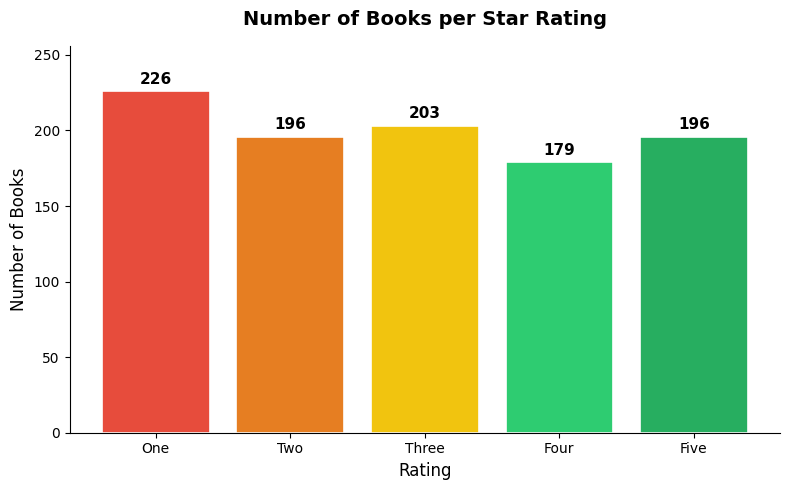

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

rating_counts = df["rating"].value_counts().reindex(["One","Two","Three","Four","Five"])
colors = ["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#27ae60"]

bars = ax.bar(rating_counts.index, rating_counts.values, color=colors, edgecolor="white", linewidth=1.2)

for bar, val in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(val), ha="center", va="bottom", fontweight="bold", fontsize=11)

ax.set_title("Number of Books per Star Rating", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Rating", fontsize=12)
ax.set_ylabel("Number of Books", fontsize=12)
ax.set_ylim(0, rating_counts.max() + 30)
sns.despine()
plt.tight_layout()
plt.show()


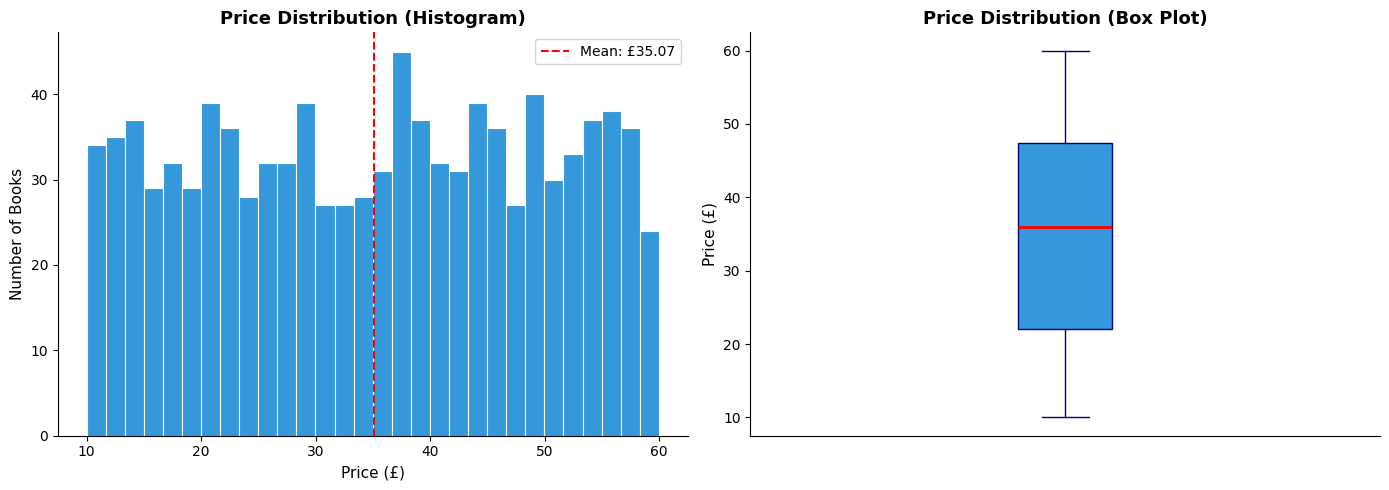

Min price: £10.00
Max price: £59.99
Average price: £35.07


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["price"], bins=30, color="#3498db", edgecolor="white", linewidth=0.8)
axes[0].set_title("Price Distribution (Histogram)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Price (£)", fontsize=11)
axes[0].set_ylabel("Number of Books", fontsize=11)
axes[0].axvline(df["price"].mean(), color="red", linestyle="--", linewidth=1.5, label=f'Mean: £{df["price"].mean():.2f}')
axes[0].legend()
sns.despine(ax=axes[0])

axes[1].boxplot(df["price"], vert=True, patch_artist=True,
                boxprops=dict(facecolor="#3498db", color="navy"),
                medianprops=dict(color="red", linewidth=2),
                whiskerprops=dict(color="navy"),
                capprops=dict(color="navy"),
                flierprops=dict(marker="o", color="gray", alpha=0.5))
axes[1].set_title("Price Distribution (Box Plot)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Price (£)", fontsize=11)
axes[1].set_xticks([])
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()
print(f"Min price: £{df['price'].min():.2f}")
print(f"Max price: £{df['price'].max():.2f}")
print(f"Average price: £{df['price'].mean():.2f}")


C:\Users\user\AppData\Local\Temp\ipykernel_2088\161177671.py:49: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_2088\161177671.py:50: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) DejaVu Sans.
  plt.savefig("books_dashboard.png", dpi=150, bbox_inches="tight")
C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


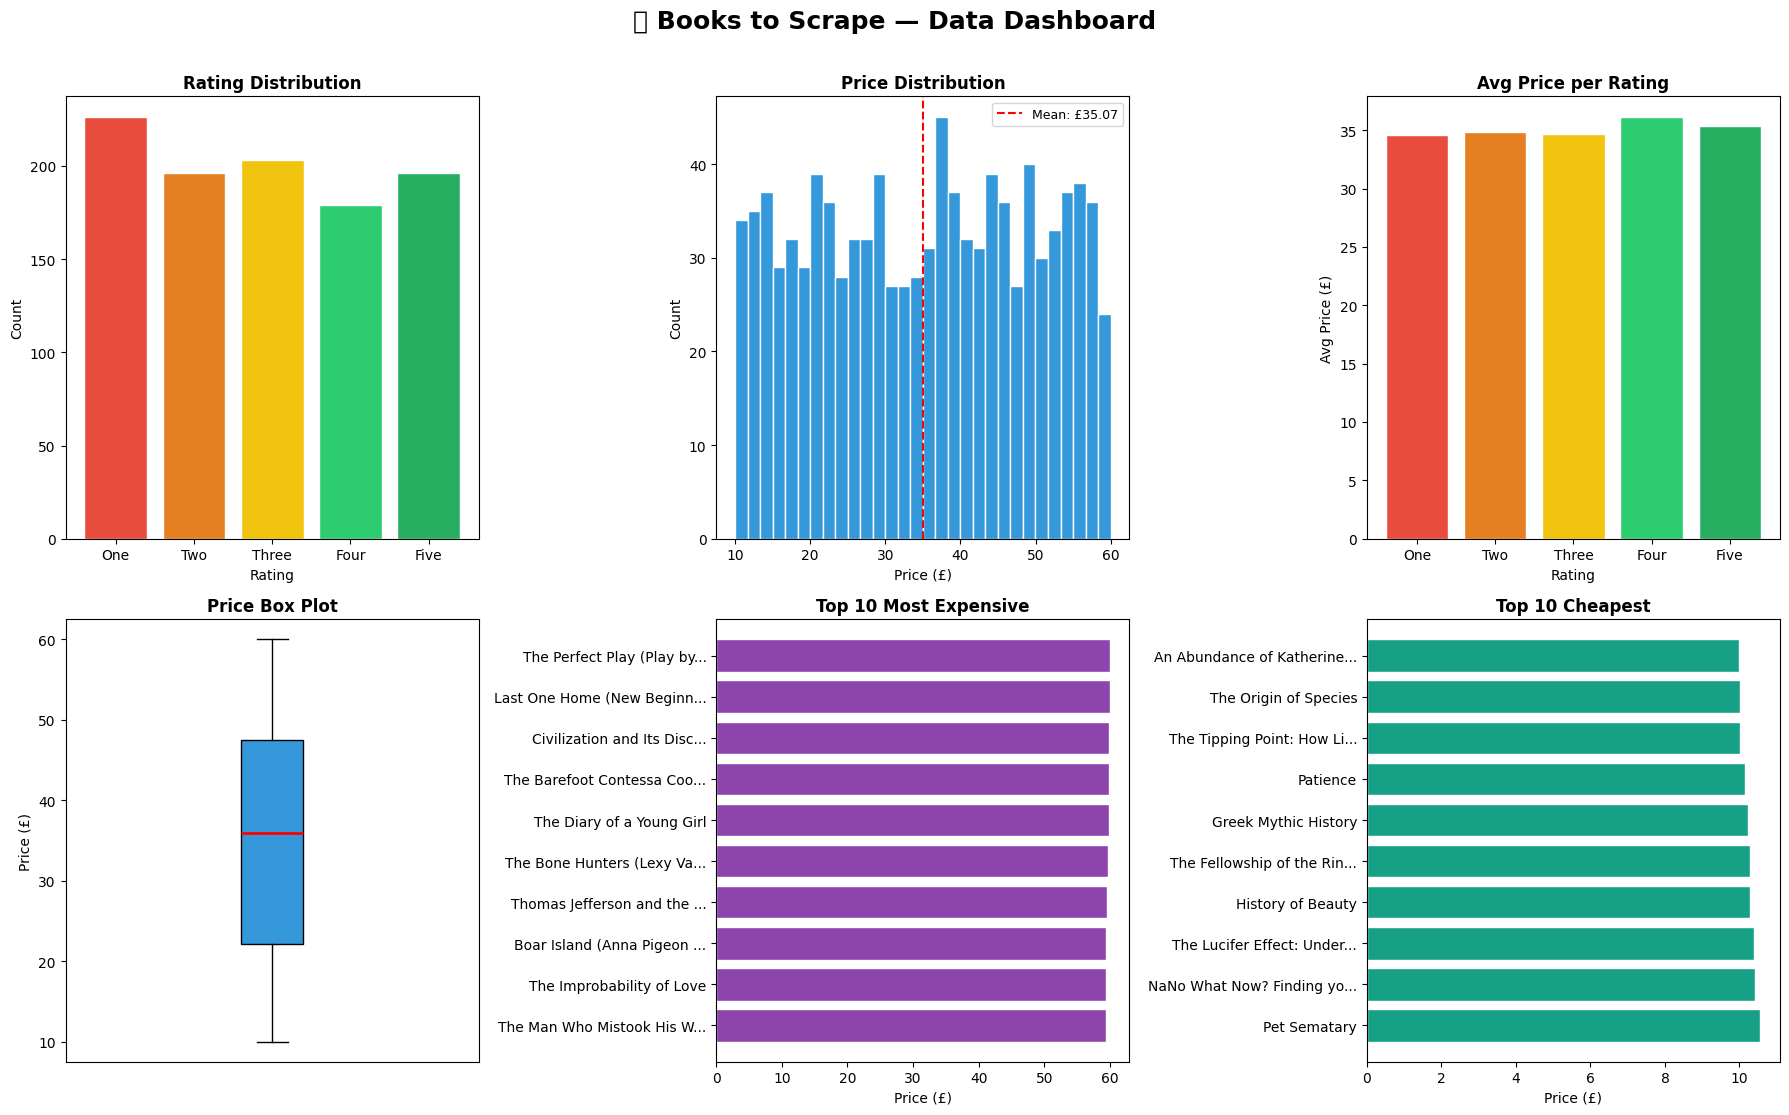

Dashboard saved as books_dashboard.png


In [31]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("📚 Books to Scrape — Data Dashboard", fontsize=18, fontweight="bold", y=1.01)

# --- Chart 1: Rating Distribution ---
rating_counts = df["rating"].value_counts().reindex(["One","Two","Three","Four","Five"])
colors = ["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#27ae60"]
axes[0,0].bar(rating_counts.index, rating_counts.values, color=colors, edgecolor="white")
axes[0,0].set_title("Rating Distribution", fontweight="bold")
axes[0,0].set_xlabel("Rating")
axes[0,0].set_ylabel("Count")

# --- Chart 2: Price Histogram ---
axes[0,1].hist(df["price"], bins=30, color="#3498db", edgecolor="white")
axes[0,1].axvline(df["price"].mean(), color="red", linestyle="--", label=f'Mean: £{df["price"].mean():.2f}')
axes[0,1].set_title("Price Distribution", fontweight="bold")
axes[0,1].set_xlabel("Price (£)")
axes[0,1].set_ylabel("Count")
axes[0,1].legend(fontsize=9)

# --- Chart 3: Avg Price per Rating ---
avg_price = df.groupby("rating")["price"].mean().reindex(["One","Two","Three","Four","Five"])
axes[0,2].bar(avg_price.index, avg_price.values, color=colors, edgecolor="white")
axes[0,2].set_title("Avg Price per Rating", fontweight="bold")
axes[0,2].set_xlabel("Rating")
axes[0,2].set_ylabel("Avg Price (£)")

# --- Chart 4: Box plot ---
axes[1,0].boxplot(df["price"], patch_artist=True,
                  boxprops=dict(facecolor="#3498db"),
                  medianprops=dict(color="red", linewidth=2))
axes[1,0].set_title("Price Box Plot", fontweight="bold")
axes[1,0].set_ylabel("Price (£)")
axes[1,0].set_xticks([])

# --- Chart 5: Top 10 Expensive ---
top10 = df.nlargest(10, "price")
short = [t[:25]+"..." if len(t)>25 else t for t in top10["title"]]
axes[1,1].barh(short[::-1], top10["price"].values[::-1], color="#8e44ad", edgecolor="white")
axes[1,1].set_title("Top 10 Most Expensive", fontweight="bold")
axes[1,1].set_xlabel("Price (£)")

# --- Chart 6: Top 10 Cheapest ---
bot10 = df.nsmallest(10, "price")
short2 = [t[:25]+"..." if len(t)>25 else t for t in bot10["title"]]
axes[1,2].barh(short2[::-1], bot10["price"].values[::-1], color="#16a085", edgecolor="white")
axes[1,2].set_title("Top 10 Cheapest", fontweight="bold")
axes[1,2].set_xlabel("Price (£)")

plt.tight_layout()
plt.savefig("books_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved as books_dashboard.png")
